In [26]:
import os
print("현재 폴더:", os.getcwd())
print()
print("이 폴더 안의 파일/폴더:")
for item in os.listdir('.'):
    print(" -", item)

현재 폴더: c:\Users\poror\OneDrive\바탕 화면\Projects\추천시스템

이 폴더 안의 파일/폴더:
 - .git
 - .gitignore
 - 01_Exploratory-Analysis-on-100K-data.ipynb
 - k_sweep.png
 - ml-100k
 - ml-100k (1).zip
 - movie_data.ipynb
 - README.md


In [27]:
import pandas as pd

train = pd.read_csv(
    'ml-100k/ua.base',
    sep='\t',
    names=['user', 'item', 'rating', 'timestamp']
)

print("총 평점 개수:", len(train))
print(train.head())

총 평점 개수: 90570
   user  item  rating  timestamp
0     1     1       5  874965758
1     1     2       3  876893171
2     1     3       4  878542960
3     1     4       3  876893119
4     1     5       3  889751712


In [28]:
import os
print(os.listdir('ml-100k'))

['allbut.pl', 'mku.sh', 'README', 'u.data', 'u.genre', 'u.info', 'u.item', 'u.occupation', 'u.user', 'u1.base', 'u1.test', 'u2.base', 'u2.test', 'u3.base', 'u3.test', 'u4.base', 'u4.test', 'u5.base', 'u5.test', 'ua.base', 'ua.test', 'ub.base', 'ub.test']


In [29]:
%pip install pandas numpy matplotlib
%pip install --upgrade pip
import pandas as pd

train = pd.read_csv(
    'ml-100k/ua.base',
    sep='\t',
    names=['user', 'item', 'rating', 'timestamp']
)

print("총 평점 개수:", len(train))
print("첫 5줄:")
print(train.head())

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
총 평점 개수: 90570
첫 5줄:
   user  item  rating  timestamp
0     1     1       5  874965758
1     1     2       3  876893171
2     1     3       4  878542960
3     1     4       3  876893119
4     1     5       3  889751712


user  item  rating  timestamp
0     1     1       5  874965758

user 1번 사용자가
item 1번 영화에
5점 평점을 매겼고
그 시각이 timestamp 874965758 (1997년 9월 20일이라는 뜻, 유닉스 시간이라서 사람이 읽기 힘듦)

In [30]:
print("사용자 수:", train['user'].nunique())
print("영화 수:", train['item'].nunique())
print()
print("평점 분포:")
print(train['rating'].value_counts().sort_index())

사용자 수: 943
영화 수: 1680

평점 분포:
rating
1     5568
2    10375
3    24721
4    30858
5    19048
Name: count, dtype: int64


In [31]:
import numpy as np

# 매번 같은 결과 나오게 시드 고정
np.random.seed(42)

# 인덱스를 무작위로 섞어서 85% / 15%로 자르기
n = len(train)
indices = np.random.permutation(n)
split = int(n * 0.85)

train_set = train.iloc[indices[:split]].reset_index(drop=True)
val_set   = train.iloc[indices[split:]].reset_index(drop=True)

print("학습:", len(train_set))
print("검증:", len(val_set))

학습: 76984
검증: 13586


In [32]:
# 학습 데이터의 전체 평균
global_mean = train_set['rating'].mean()
print("전체 평균:", round(global_mean, 4))

# 검증셋 모든 평점을 "그냥 평균"으로만 예측
predictions = np.full(len(val_set), global_mean)
actuals = val_set['rating'].values

# RMSE 계산
rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
print("베이스라인 RMSE:", round(rmse, 4))

전체 평균: 3.5234
베이스라인 RMSE: 1.134


In [33]:
# pandas에서 인덱스로 쓰려면 1부터가 아닌 0부터여야 편함
train_set = train_set.copy()
val_set = val_set.copy()

train_set['user'] = train_set['user'] - 1
train_set['item'] = train_set['item'] - 1
val_set['user'] = val_set['user'] - 1
val_set['item'] = val_set['item'] - 1

n_users = 943
n_items = 1682

print("user 범위:", train_set['user'].min(), "~", train_set['user'].max())
print("item 범위:", train_set['item'].min(), "~", train_set['item'].max())

user 범위: 0 ~ 942
item 범위: 0 ~ 1681


In [34]:
np.random.seed(42)
k = 20  # 잠재 요인 개수 (hyperparameter, 보통 10~50)

# 작은 무작위 수로 초기화 (정확히 0이면 학습이 안 됨)
P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))

print("P shape:", P.shape)
print("Q shape:", Q.shape)

P shape: (943, 20)
Q shape: (1682, 20)


In [35]:
lr = 0.005     # learning rate
epochs = 10    # 전체 데이터를 몇 바퀴 돌릴지

# 미리 numpy 배열로 뽑아두기 (속도 ↑)
users   = train_set['user'].values
items   = train_set['item'].values
ratings = train_set['rating'].values

for epoch in range(epochs):
    # 매 epoch마다 순서 섞기
    order = np.random.permutation(len(ratings))
    sse = 0.0  # 제곱 오차 합

    for idx in order:
        u = users[idx]
        i = items[idx]
        r = ratings[idx]

        pred = P[u] @ Q[i]   # 예측 = 두 벡터 내적
        err  = r - pred
        sse += err * err

        # ⚠️ P[u]를 업데이트하기 전에 복사 (Q[i] 업데이트할 때 직전 값 써야 함)
        p_old = P[u].copy()
        P[u] = P[u] + lr * err * Q[i]
        Q[i] = Q[i] + lr * err * p_old

    train_rmse = np.sqrt(sse / len(ratings))
    print(f"epoch {epoch+1:2d}/{epochs}  train RMSE = {train_rmse:.4f}")

epoch  1/10  train RMSE = 3.6930
epoch  2/10  train RMSE = 3.2444
epoch  3/10  train RMSE = 1.8784
epoch  4/10  train RMSE = 1.3661
epoch  5/10  train RMSE = 1.1762
epoch  6/10  train RMSE = 1.0822
epoch  7/10  train RMSE = 1.0273
epoch  8/10  train RMSE = 0.9914
epoch  9/10  train RMSE = 0.9654
epoch 10/10  train RMSE = 0.9451


In [36]:
val_users   = val_set['user'].values
val_items   = val_set['item'].values
val_ratings = val_set['rating'].values

# 한 방에 모든 검증 평점 예측
val_preds = np.sum(P[val_users] * Q[val_items], axis=1)
val_rmse = np.sqrt(np.mean((val_preds - val_ratings) ** 2))

print(f"Stage 1 검증 RMSE: {val_rmse:.4f}")
print(f"베이스라인 RMSE:    1.1340")
print(f"개선폭:             {1.134 - val_rmse:.4f}")

Stage 1 검증 RMSE: 0.9943
베이스라인 RMSE:    1.1340
개선폭:             0.1397


In [37]:
np.random.seed(42)
P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))

lr = 0.005
epochs = 10
reg = 0.02       # ⭐ 새로 추가: λ (정규화 강도)

for epoch in range(epochs):
    order = np.random.permutation(len(ratings))
    sse = 0.0

    for idx in order:
        u = users[idx]
        i = items[idx]
        r = ratings[idx]

        pred = P[u] @ Q[i]
        err  = r - pred
        sse += err * err

        p_old = P[u].copy()
        # ⭐ 두 줄에 - reg * P[u], - reg * Q[i] 한 항씩 추가
        P[u] = P[u] + lr * (err * Q[i] - reg * P[u])
        Q[i] = Q[i] + lr * (err * p_old - reg * Q[i])

    train_rmse = np.sqrt(sse / len(ratings))
    print(f"epoch {epoch+1:2d}/{epochs}  train RMSE = {train_rmse:.4f}")

epoch  1/10  train RMSE = 3.6932
epoch  2/10  train RMSE = 3.2592
epoch  3/10  train RMSE = 1.8936
epoch  4/10  train RMSE = 1.3726
epoch  5/10  train RMSE = 1.1807
epoch  6/10  train RMSE = 1.0862
epoch  7/10  train RMSE = 1.0314
epoch  8/10  train RMSE = 0.9962
epoch  9/10  train RMSE = 0.9711
epoch 10/10  train RMSE = 0.9520


In [38]:
val_preds = np.sum(P[val_users] * Q[val_items], axis=1)
val_rmse = np.sqrt(np.mean((val_preds - val_ratings) ** 2))

print(f"Stage 2 검증 RMSE: {val_rmse:.4f}")
print(f"Stage 1 검증 RMSE: 0.9943")

Stage 2 검증 RMSE: 0.9957
Stage 1 검증 RMSE: 0.9943


In [39]:
np.random.seed(42)
P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))

# ⭐ 새로 추가: bias terms
mu = train_set['rating'].mean()
bu = np.zeros(n_users)
bi = np.zeros(n_items)

lr = 0.005
epochs = 20      # ⭐ 20으로 늘림 (Stage 2에서 수렴 안 했음)
reg = 0.02

for epoch in range(epochs):
    order = np.random.permutation(len(ratings))
    sse = 0.0

    for idx in order:
        u = users[idx]
        i = items[idx]
        r = ratings[idx]

        # ⭐ 예측에 mu + bu + bi 추가
        pred = mu + bu[u] + bi[i] + P[u] @ Q[i]
        err = r - pred
        sse += err * err

        # ⭐ bias 업데이트 추가
        bu[u] += lr * (err - reg * bu[u])
        bi[i] += lr * (err - reg * bi[i])

        # P, Q 업데이트 (Stage 2와 동일)
        p_old = P[u].copy()
        P[u] = P[u] + lr * (err * Q[i] - reg * P[u])
        Q[i] = Q[i] + lr * (err * p_old - reg * Q[i])

    train_rmse = np.sqrt(sse / len(ratings))
    print(f"epoch {epoch+1:2d}/{epochs}  train RMSE = {train_rmse:.4f}")

epoch  1/20  train RMSE = 1.0462
epoch  2/20  train RMSE = 0.9805
epoch  3/20  train RMSE = 0.9573
epoch  4/20  train RMSE = 0.9444
epoch  5/20  train RMSE = 0.9356
epoch  6/20  train RMSE = 0.9289
epoch  7/20  train RMSE = 0.9234
epoch  8/20  train RMSE = 0.9186
epoch  9/20  train RMSE = 0.9142
epoch 10/20  train RMSE = 0.9100
epoch 11/20  train RMSE = 0.9059
epoch 12/20  train RMSE = 0.9016
epoch 13/20  train RMSE = 0.8972
epoch 14/20  train RMSE = 0.8924
epoch 15/20  train RMSE = 0.8873
epoch 16/20  train RMSE = 0.8817
epoch 17/20  train RMSE = 0.8756
epoch 18/20  train RMSE = 0.8690
epoch 19/20  train RMSE = 0.8619
epoch 20/20  train RMSE = 0.8546


In [40]:
val_preds = (mu
             + bu[val_users]
             + bi[val_items]
             + np.sum(P[val_users] * Q[val_items], axis=1))

val_rmse = np.sqrt(np.mean((val_preds - val_ratings) ** 2))

print(f"Stage 3 검증 RMSE: {val_rmse:.4f}")
print(f"Stage 2 검증 RMSE: 0.9957")
print(f"Stage 1 검증 RMSE: 0.9943")
print(f"베이스라인 RMSE:    1.1340")

Stage 3 검증 RMSE: 0.9360
Stage 2 검증 RMSE: 0.9957
Stage 1 검증 RMSE: 0.9943
베이스라인 RMSE:    1.1340


In [41]:
# 1. 사용자별 평가한 아이템 목록 미리 계산 (속도)
user_rated_items = {}
for u, group in train_set.groupby('user'):
    user_rated_items[u] = group['item'].values

# 2. 초기화
np.random.seed(42)
P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))
Y = np.random.normal(0, 0.1, (n_items, k))   # ⭐ 새 행렬

mu = train_set['rating'].mean()
bu = np.zeros(n_users)
bi = np.zeros(n_items)

lr = 0.005
epochs = 20        # Stage 4는 무거워서 10으로
reg = 0.02

# 3. 학습
for epoch in range(epochs):
    order = np.random.permutation(len(ratings))
    sse = 0.0

    for idx in order:
        u = users[idx]
        i = items[idx]
        r = ratings[idx]

        # ⭐ implicit feedback 계산
        I_u = user_rated_items[u]
        norm = 1.0 / np.sqrt(len(I_u))
        sum_y = Y[I_u].sum(axis=0)
        p_aug = P[u] + norm * sum_y          # augmented user vector

        pred = mu + bu[u] + bi[i] + p_aug @ Q[i]
        err = r - pred
        sse += err * err

        # 업데이트
        bu[u] += lr * (err - reg * bu[u])
        bi[i] += lr * (err - reg * bi[i])

        p_old = P[u].copy()
        P[u] += lr * (err * Q[i] - reg * P[u])
        Q[i] += lr * (err * p_aug - reg * Q[i])      # ⭐ Q는 p_aug 사용

        # ⭐ Y 업데이트 (한 번에 평가한 모든 아이템에 대해, 벡터화)
        Y[I_u] += lr * (err * norm * Q[i] - reg * Y[I_u])

    train_rmse = np.sqrt(sse / len(ratings))
    print(f"epoch {epoch+1:2d}/{epochs}  train RMSE = {train_rmse:.4f}")

epoch  1/20  train RMSE = 1.0448
epoch  2/20  train RMSE = 0.9757
epoch  3/20  train RMSE = 0.9512
epoch  4/20  train RMSE = 0.9374
epoch  5/20  train RMSE = 0.9279
epoch  6/20  train RMSE = 0.9204
epoch  7/20  train RMSE = 0.9138
epoch  8/20  train RMSE = 0.9078
epoch  9/20  train RMSE = 0.9019
epoch 10/20  train RMSE = 0.8958
epoch 11/20  train RMSE = 0.8895
epoch 12/20  train RMSE = 0.8830
epoch 13/20  train RMSE = 0.8764
epoch 14/20  train RMSE = 0.8695
epoch 15/20  train RMSE = 0.8625
epoch 16/20  train RMSE = 0.8553
epoch 17/20  train RMSE = 0.8483
epoch 18/20  train RMSE = 0.8411
epoch 19/20  train RMSE = 0.8340
epoch 20/20  train RMSE = 0.8268


In [42]:
# augmented P 계산
P_aug = P.copy()
for u in range(n_users):
    if u in user_rated_items:
        I_u = user_rated_items[u]
        norm = 1.0 / np.sqrt(len(I_u))
        P_aug[u] += norm * Y[I_u].sum(axis=0)

val_preds = (mu
             + bu[val_users]
             + bi[val_items]
             + np.sum(P_aug[val_users] * Q[val_items], axis=1))

val_rmse = np.sqrt(np.mean((val_preds - val_ratings) ** 2))

print(f"Stage 4 (epoch 20) 검증 RMSE: {val_rmse:.4f}")
print(f"Stage 3 (epoch 20) 검증 RMSE: 0.9360")

Stage 4 (epoch 20) 검증 RMSE: 0.9198
Stage 3 (epoch 20) 검증 RMSE: 0.9360



=== k = 5 학습 중 ===
  val RMSE = 0.9259,  학습 시간 = 86.9s

=== k = 10 학습 중 ===
  val RMSE = 0.9238,  학습 시간 = 90.4s

=== k = 20 학습 중 ===
  val RMSE = 0.9198,  학습 시간 = 113.4s

=== k = 50 학습 중 ===
  val RMSE = 0.9196,  학습 시간 = 150.0s

=== k = 100 학습 중 ===
  val RMSE = 0.9242,  학습 시간 = 198.4s

=== K sweep 결과 ===
     k  val_rmse        time
0    5  0.925894   86.945587
1   10  0.923824   90.424288
2   20  0.919805  113.388497
3   50  0.919574  150.041013
4  100  0.924227  198.393393


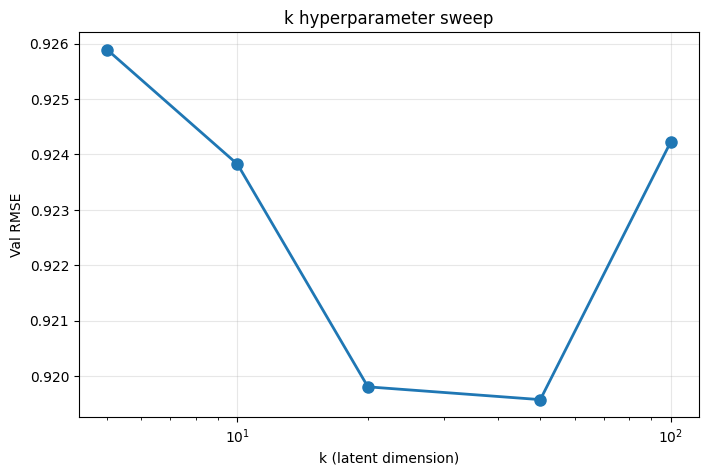

<Figure size 640x480 with 0 Axes>

In [43]:
import time

k_values = [5, 10, 20, 50, 100]
results = []

for k_test in k_values:
    print(f"\n=== k = {k_test} 학습 중 ===")
    start = time.time()
    
    # 초기화
    np.random.seed(42)
    P = np.random.normal(0, 0.1, (n_users, k_test))
    Q = np.random.normal(0, 0.1, (n_items, k_test))
    Y = np.random.normal(0, 0.1, (n_items, k_test))
    bu = np.zeros(n_users)
    bi = np.zeros(n_items)
    
    epochs = 20
    lr = 0.005
    reg = 0.02
    
    for epoch in range(epochs):
        order = np.random.permutation(len(ratings))
        for idx in order:
            u, i, r = users[idx], items[idx], ratings[idx]
            I_u = user_rated_items[u]
            norm = 1.0 / np.sqrt(len(I_u))
            sum_y = Y[I_u].sum(axis=0)
            p_aug = P[u] + norm * sum_y
            
            pred = mu + bu[u] + bi[i] + p_aug @ Q[i]
            err = r - pred
            
            bu[u] += lr * (err - reg * bu[u])
            bi[i] += lr * (err - reg * bi[i])
            P[u] += lr * (err * Q[i] - reg * P[u])
            Q[i] += lr * (err * p_aug - reg * Q[i])
            Y[I_u] += lr * (err * norm * Q[i] - reg * Y[I_u])
    
    # 검증 RMSE 계산
    P_aug = P.copy()
    for u in range(n_users):
        if u in user_rated_items:
            I_u = user_rated_items[u]
            norm = 1.0 / np.sqrt(len(I_u))
            P_aug[u] += norm * Y[I_u].sum(axis=0)
    
    val_preds = mu + bu[val_users] + bi[val_items] + np.sum(P_aug[val_users] * Q[val_items], axis=1)
    val_rmse = np.sqrt(np.mean((val_preds - val_ratings) ** 2))
    
    elapsed = time.time() - start
    print(f"  val RMSE = {val_rmse:.4f},  학습 시간 = {elapsed:.1f}s")
    results.append({'k': k_test, 'val_rmse': val_rmse, 'time': elapsed})

# 표로 정리
import pandas as pd
df = pd.DataFrame(results)
print("\n=== K sweep 결과 ===")
print(df)

# 그래프
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(df['k'], df['val_rmse'], 'o-', linewidth=2, markersize=8)
plt.xlabel('k (latent dimension)')
plt.ylabel('Val RMSE')
plt.title('k hyperparameter sweep')
plt.grid(alpha=0.3)
plt.xscale('log')
plt.show()
plt.savefig('k_sweep.png', dpi=150, bbox_inches='tight')

In [44]:
#최종 모델 학습 (k=20)
np.random.seed(42)
k = 20
P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))
Y = np.random.normal(0, 0.1, (n_items, k))
bu = np.zeros(n_users)
bi = np.zeros(n_items)
mu = train_set['rating'].mean()
lr, epochs, reg = 0.005, 20, 0.02

for epoch in range(epochs):
    order = np.random.permutation(len(ratings))
    for idx in order:
        u, i, r = users[idx], items[idx], ratings[idx]
        I_u = user_rated_items[u]
        norm = 1.0 / np.sqrt(len(I_u))
        p_aug = P[u] + norm * Y[I_u].sum(axis=0)
        err = r - (mu + bu[u] + bi[i] + p_aug @ Q[i])
        bu[u] += lr * (err - reg * bu[u])
        bi[i] += lr * (err - reg * bi[i])
        P[u] += lr * (err * Q[i] - reg * P[u])
        Q[i] += lr * (err * p_aug - reg * Q[i])
        Y[I_u] += lr * (err * norm * Q[i] - reg * Y[I_u])
print("최종 모델 학습 완료 (k=20)")

최종 모델 학습 완료 (k=20)


In [45]:
#모든 사용자에게 top-k 추천 생성
K = 10  # 추천 개수

# augmented P
P_aug = P.copy()
for u in range(n_users):
    if u in user_rated_items:
        I_u = user_rated_items[u]
        norm = 1.0 / np.sqrt(len(I_u))
        P_aug[u] += norm * Y[I_u].sum(axis=0)

# 학습데이터에서 이미 평가한 아이템 (추천 제외용)
train_items_per_user = {u: set(its) for u, its in user_rated_items.items()}

recommendations = {}
for u in range(n_users):
    scores = mu + bu[u] + bi + P_aug[u] @ Q.T   # 모든 아이템 점수
    for i in train_items_per_user.get(u, set()):
        scores[i] = -np.inf                       # 이미 본 건 제외
    topk = np.argpartition(-scores, K)[:K]
    topk = topk[np.argsort(-scores[topk])]
    recommendations[u] = topk.tolist()

print(f"추천 생성 완료: {len(recommendations)}명 × {K}개")

추천 생성 완료: 943명 × 10개


In [48]:
# 아이템 인기도 (ua.base 평가 횟수)
popularity_counts = np.bincount(items, minlength=n_items)

# 인기 top-K (의외성 baseline = "뻔한 추천")
popular_topk = set(np.argsort(-popularity_counts)[:K].tolist())

In [49]:
# 커버리지: 추천에 등장한 unique 아이템 비율
def coverage(recs, n_items):
    rec_set = set()
    for its in recs.values():
        rec_set.update(its)
    return len(rec_set) / n_items

# 의외성: top-K 중 인기 baseline에 없는 비율 (강의 7.3 정의)
def serendipity(recs, popular_set, K):
    s = [sum(1 for i in its[:K] if i not in popular_set) / K
         for its in recs.values()]
    return np.mean(s)

# 참신성: 추천 아이템의 평균 정보량 -log2(인기도). 높을수록 덜 알려진 아이템
def novelty(recs, pop_counts, n_users, K):
    s = []
    for its in recs.values():
        novs = [-np.log2(max(pop_counts[i] / n_users, 1e-9)) for i in its[:K]]
        s.append(np.mean(novs))
    return np.mean(s)

# 다양성: 추천 리스트 내 아이템 간 평균 비유사도 (Q 벡터 코사인 기반)
def diversity(recs, Q, K):
    s = []
    for its in recs.values():
        topk = its[:K]
        if len(topk) < 2:
            continue
        vecs = Q[topk]
        normed = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)
        sim = normed @ normed.T
        n = len(topk)
        avg_sim = np.sum(np.triu(sim, k=1)) / (n * (n - 1) / 2)
        s.append(1 - avg_sim)   # 다양성 = 1 - 유사도
    return np.mean(s)

# 실행
print(f"=== 정확성 외 메트릭 (Stage 4 MF, K={K}) ===")
print(f"커버리지 (Coverage)    : {coverage(recommendations, n_items):.4f}")
print(f"의외성   (Serendipity) : {serendipity(recommendations, popular_topk, K):.4f}")
print(f"참신성   (Novelty)     : {novelty(recommendations, popularity_counts, n_users, K):.4f}")
print(f"다양성   (Diversity)   : {diversity(recommendations, Q, K):.4f}")

=== 정확성 외 메트릭 (Stage 4 MF, K=10) ===
커버리지 (Coverage)    : 0.0945
의외성   (Serendipity) : 0.9380
참신성   (Novelty)     : 2.7111
다양성   (Diversity)   : 0.6316


In [51]:
ratings_per_user = train_set.groupby('user').size()
print(f"사용자당 평점 수 — 평균 {ratings_per_user.mean():.0f}, "
      f"중앙값 {ratings_per_user.median():.0f}, "
      f"최소 {ratings_per_user.min()}, 최대 {ratings_per_user.max()}")

사용자당 평점 수 — 평균 82, 중앙값 46, 최소 6, 최대 629


In [52]:
val_relevant = val_set[val_set['rating'] >= 4].groupby('user').size()
print(f"검증셋 사용자당 relevant(평점>=4) — 평균 {val_relevant.mean():.1f}, "
      f"중앙값 {val_relevant.median():.0f}")

검증셋 사용자당 relevant(평점>=4) — 평균 8.7, 중앙값 5


In [53]:
ratings_per_user = train_set.groupby('user').size()

def user_group(u):
    n = ratings_per_user.get(u, 0)
    if n < 30:   return '1_cold (<30)'
    elif n < 80: return '2_medium (30-80)'
    else:        return '3_active (80+)'

vu = val_set['user'].values
vi = val_set['item'].values
vr = val_set['rating'].values
val_pred = mu + bu[vu] + bi[vi] + np.sum(P_aug[vu]*Q[vi], axis=1)

val_g = val_set.copy()
val_g['group'] = val_g['user'].map(user_group)
val_g['sq_err'] = (val_pred - vr) ** 2

print("그룹별 RMSE:")
for g, grp in val_g.groupby('group'):
    rmse = np.sqrt(grp['sq_err'].mean())
    print(f"  {g}: RMSE={rmse:.4f} (평가 {len(grp)}건)")

그룹별 RMSE:
  1_cold (<30): RMSE=1.0266 (평가 976건)
  2_medium (30-80): RMSE=0.9316 (평가 2047건)
  3_active (80+): RMSE=0.9070 (평가 10563건)
